# C3 - Dreaddit: Preprocessing 

In [52]:
import re, os, json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')

from sklearn.model_selection   import train_test_split
from sklearn.preprocessing     import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from dotenv          import load_dotenv
from huggingface_hub import login

OUTPUT_DIR  = '../../../reports/c3_text_stressor_distortion/Stress header/'
DATA_OUTPUT_DIR = '../../../data/Stress header/processed/'
RANDOM_SEED = 42
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(DATA_OUTPUT_DIR, exist_ok=True)


# Transformer models
MODEL_REGISTRY = [
    {
        'name'      : 'BERT',
        'hf_id'     : 'bert-base-uncased',
        'text_col'  : 'text_for_bert',
        'lowercase' : True,
        'max_tokens': 512,
        'note'      : 'Transformer baseline — WordPiece tokenizer, must be lowercase'
    },
    {
        'name'      : 'MentalBERT',
        'hf_id'     : 'mental/mental-bert-base-uncased',
        'text_col'  : 'text_for_mentalbert',
        'lowercase' : True,
        'max_tokens': 512,
        'note'      : 'Pretrained on mental health Reddit+Twitter — domain specific!'
    },
    {
        'name'      : 'DeBERTa-v3',
        'hf_id'     : 'microsoft/deberta-v3-base',
        'text_col'  : 'text_for_deberta',
        'lowercase' : True,
        'max_tokens': 512,
        'note'      : 'SOTA classification — ELECTRA pretraining + disentangled attention'
    },
]

#ML baselines
ML_BASELINES = ['TF-IDF + LR', 'TF-IDF + SVM']

print(f'Transformer models : {len(MODEL_REGISTRY)}')
for m in MODEL_REGISTRY:
    print(f'  [{m["name"]:12s}] {m["hf_id"]}')
    print(f'               {m["note"]}')

print(f'\nML Baselines : {len(ML_BASELINES)}')
for b in ML_BASELINES:
    print(f'  {b}')


Transformer models : 3
  [BERT        ] bert-base-uncased
               Transformer baseline — WordPiece tokenizer, must be lowercase
  [MentalBERT  ] mental/mental-bert-base-uncased
               Pretrained on mental health Reddit+Twitter — domain specific!
  [DeBERTa-v3  ] microsoft/deberta-v3-base
               SOTA classification — ELECTRA pretraining + disentangled attention

ML Baselines : 2
  TF-IDF + LR
  TF-IDF + SVM


In [53]:
train_raw = pd.read_parquet('../../../data/Stress header/raw/Dreaddit/train-00000-of-00001.parquet')
test_raw = pd.read_parquet('../../../data/Stress header/raw/Dreaddit/test-00000-of-00001.parquet')


KEEP     = ['text', 'label', 'subreddit', 'confidence', 'sentiment']
train_df = train_raw[KEEP].copy()
test_df  = test_raw[KEEP].copy()

print(f'Train: {train_df.shape} | Test: {test_df.shape}')
print(f'\nLabel distribution:')
print(train_df['label'].value_counts())
print(f'\nSubreddit distribution:')
print(train_df['subreddit'].value_counts())

Train: (2838, 5) | Test: (715, 5)

Label distribution:
label
1    1488
0    1350
Name: count, dtype: int64

Subreddit distribution:
subreddit
ptsd                584
relationships       552
anxiety             503
domesticviolence    316
assistance          289
survivorsofabuse    245
homeless            168
almosthomeless       80
stress               64
food_pantry          37
Name: count, dtype: int64


In [54]:
#Contraction Dictionary
CONTRACTIONS = {
    # Negatives
    "can't": "cannot", "won't": "will not", "don't": "do not",
    "doesn't": "does not", "didn't": "did not", "wouldn't": "would not",
    "couldn't": "could not", "shouldn't": "should not", "isn't": "is not",
    "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "haven't": "have not", "hasn't": "has not", "hadn't": "had not",
    "mustn't": "must not", "needn't": "need not",
    # Personal pronouns
    "i'm": "i am", "i've": "i have", "i'll": "i will", "i'd": "i would",
    "you're": "you are", "you've": "you have", "you'll": "you will",
    "he's": "he is", "she's": "she is", "it's": "it is",
    "we're": "we are", "we've": "we have", "we'll": "we will",
    "they're": "they are", "they've": "they have", "they'll": "they will",
    "that's": "that is", "there's": "there is", "what's": "what is",
    "who's": "who is", "let's": "let us", "how's": "how is",
    # Reddit/Internet slang
    "rn": "right now", "tbh": "to be honest", "idk": "i do not know",
    "imo": "in my opinion", "imho": "in my humble opinion",
    "omg": "oh my god", "bc": "because", "b/c": "because",
    "tho": "though", "gonna": "going to", "wanna": "want to",
    "gotta": "got to", "kinda": "kind of", "sorta": "sort of",
    "ngl": "not going to lie", "irl": "in real life",
    "smh": "shaking my head", "nvm": "never mind",
    "afaik": "as far as i know", "fwiw": "for what it is worth",
    "tldr": "too long did not read", "asap": "as soon as possible",
    "lol": "", "lmao": "", "lmfao": "", "rofl": "",
    "wtf": "", "omfg": "", "smfh": "",
}

def expand_contractions(text):
    for k, v in CONTRACTIONS.items():
        text = re.sub(r'\b' + re.escape(k) + r'\b', v, text)
    return text

# Test
t = "I can't handle this rn tbh, I'm sooo stressed idk what to do"
print(f'Before: {t}')
print(f'After : {expand_contractions(t.lower())}')
print(f'\n{len(CONTRACTIONS)} contraction patterns loaded!')


Before: I can't handle this rn tbh, I'm sooo stressed idk what to do
After : i cannot handle this right now to be honest, i am sooo stressed i do not know what to do

68 contraction patterns loaded!


In [55]:
# ─Base Cleaning
def remove_noise(text):
    """Remove URLs, Reddit mentions, emails, HTML — all models"""
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)
    text = re.sub(r'/?r/[A-Za-z0-9_]+', ' ', text)
    text = re.sub(r'/?u/[A-Za-z0-9_]+', ' ', text)
    text = re.sub(r'\S+@\S+\.\S+', ' ', text)
    text = re.sub(r'&[a-z]+;|&#?[a-z0-9]+;', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    return text


def normalize_repeated_chars(text):
    """sooooo → soo | !!!! → !"""
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'([!?.,;:]){2,}', r'\1', text)
    text = re.sub(r' {2,}', ' ', text)
    return text


def normalize_punctuation(text):
    """Remove markdown, keep sentence punctuation"""
    text = re.sub(r'\*{1,3}(.*?)\*{1,3}', r'\1', text)
    text = re.sub(r'_{1,2}(.*?)_{1,2}', r'\1', text)
    text = re.sub(r'~~(.*?)~~', r'\1', text)
    text = re.sub(r'^#+\s+', '', text, flags=re.M)
    text = re.sub(r'^>+\s*', '', text, flags=re.M)
    text = re.sub(r"[^a-zA-Z0-9\s\.\!\?\,\-\']", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def base_clean(text, lowercase=True):
    """Base cleaning pipeline — used by all transformer models"""
    if not isinstance(text, str) or not text.strip():
        return ''
    if lowercase:
        text = text.lower()
    text = expand_contractions(text)
    text = remove_noise(text)
    text = normalize_repeated_chars(text)
    text = normalize_punctuation(text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


In [56]:
# Model-Specific Preprocessing
def preprocess_for_bert(text):
    """
    bert-base-uncased
    WordPiece tokenizer — MUST be lowercase
    Max 512 tokens
    """
    return base_clean(text, lowercase=True)


def preprocess_for_mentalbert(text):
    """
    mental/mental-bert-base-uncased
    Pretrained on mental health Reddit + Twitter
    Keep text as natural as possible — model already knows mental health vocab
    MUST be lowercase (uncased)
    Max 512 tokens
    """
    return base_clean(text, lowercase=True)


def preprocess_for_deberta(text):
    """
    microsoft/deberta-v3-base
    SentencePiece tokenizer — ELECTRA pretraining
    Disentangled attention benefits from natural sentence structure
    Remove standalone single characters (noise)
    Max 512 tokens
    """
    if not isinstance(text, str) or not text.strip():
        return ''
    text = text.lower()
    text = expand_contractions(text)
    text = remove_noise(text)
    text = normalize_repeated_chars(text)
    text = normalize_punctuation(text)
    text = re.sub(r'\b[a-z]\b', ' ', text)   # remove single chars
    text = re.sub(r'\s+', ' ', text).strip()
    return text

PREPROCESS_FUNCS = {
    'text_for_bert'      : preprocess_for_bert,
    'text_for_mentalbert': preprocess_for_mentalbert,
    'text_for_deberta'   : preprocess_for_deberta,
}

print('All 3 transformer preprocessing functions defined!')
print('ML Baselines will use raw text column directly.\n')

# Side by side comparison
test_texts = [
    "I can't handle this anymore!!! sooooo stressed rn tbh https://help.com r/anxiety",
    "whyyyy doesn't anyone understand how I'm feeling... I've been so hopelesss lately",
]

print('SIDE-BY-SIDE COMPARISON')
print('=' * 75)
for text in test_texts:
    print(f'\nORIGINAL   : {text}')
    print(f'BERT       : {preprocess_for_bert(text)}')
    print(f'MentalBERT : {preprocess_for_mentalbert(text)}')
    print(f'DeBERTa-v3 : {preprocess_for_deberta(text)}')
    print(f'ML Baseline: {text}  ← raw text, TF-IDF handles tokenization')
    print('-' * 75)


All 3 transformer preprocessing functions defined!
ML Baselines will use raw text column directly.

SIDE-BY-SIDE COMPARISON

ORIGINAL   : I can't handle this anymore!!! sooooo stressed rn tbh https://help.com r/anxiety
BERT       : i cannot handle this anymore! soo stressed right now to be honest
MentalBERT : i cannot handle this anymore! soo stressed right now to be honest
DeBERTa-v3 : cannot handle this anymore! soo stressed right now to be honest
ML Baseline: I can't handle this anymore!!! sooooo stressed rn tbh https://help.com r/anxiety  ← raw text, TF-IDF handles tokenization
---------------------------------------------------------------------------

ORIGINAL   : whyyyy doesn't anyone understand how I'm feeling... I've been so hopelesss lately
BERT       : whyy does not anyone understand how i am feeling. i have been so hopeless lately
MentalBERT : whyy does not anyone understand how i am feeling. i have been so hopeless lately
DeBERTa-v3 : whyy does not anyone understand how am

In [57]:
# ── Cell 6: Apply Preprocessing ──────────────────────────────────────────────
for col, func in PREPROCESS_FUNCS.items():
    train_df[col] = train_df['text'].apply(func)
    model_name    = col.replace('text_for_', '').upper()
    

for col, func in PREPROCESS_FUNCS.items():
    test_df[col] = test_df['text'].apply(func)

# Length stats
print('\nText length comparison after preprocessing:')
print(f'{"Version":22s} {"Mean":>8s} {"Min":>6s} {"Max":>6s} {"Words(avg)":>12s}')
print('-' * 60)
for col in ['text'] + list(PREPROCESS_FUNCS.keys()):
    lens  = train_df[col].str.len()
    words = train_df[col].str.split().str.len()
    print(f'{col:22s} {lens.mean():>8.1f} {lens.min():>6d} {lens.max():>6d} {words.mean():>12.1f}')



Text length comparison after preprocessing:
Version                    Mean    Min    Max   Words(avg)
------------------------------------------------------------
text                      448.0      6   1639         85.7
text_for_bert             447.3      5   1643         88.3
text_for_mentalbert       447.3      5   1643         88.3
text_for_deberta          432.5      5   1598         81.0


In [58]:
# Label Encoding
print('HEAD 1A — Binary Stress Label')
vc = train_df['label'].value_counts()
for k, v in vc.items():
    name = 'Stressed' if k == 1 else 'Not Stressed'
    bar  = '█' * int(v / len(train_df) * 50)
    print(f'  {k} ({name:13s}): {v} ({v/len(train_df)*100:.1f}%) {bar}')

print('\nHEAD 1B — Subreddit (Stressor Category)')
subreddit_encoder           = LabelEncoder()
train_df['subreddit_label'] = subreddit_encoder.fit_transform(train_df['subreddit'])
test_df['subreddit_label']  = subreddit_encoder.transform(test_df['subreddit'])

SUBREDDIT_ID2NAME = {i: c for i, c in enumerate(subreddit_encoder.classes_)}
for i, cls in enumerate(subreddit_encoder.classes_):
    count = (train_df['subreddit'] == cls).sum()
    print(f'  {i:2d} = {cls:25s} ({count} samples)')

# Class weights
weights_binary = compute_class_weight(
    'balanced', classes=np.array([0, 1]), y=train_df['label'].values)
weights_sub = compute_class_weight(
    'balanced',
    classes=np.arange(len(subreddit_encoder.classes_)),
    y=train_df['subreddit_label'].values
)
print(f'\nBinary weights    : {weights_binary.round(4)}')
print(f'Subreddit weights : {weights_sub.round(4)}')


HEAD 1A — Binary Stress Label
  1 (Stressed     ): 1488 (52.4%) ██████████████████████████
  0 (Not Stressed ): 1350 (47.6%) ███████████████████████

HEAD 1B — Subreddit (Stressor Category)
   0 = almosthomeless            (80 samples)
   1 = anxiety                   (503 samples)
   2 = assistance                (289 samples)
   3 = domesticviolence          (316 samples)
   4 = food_pantry               (37 samples)
   5 = homeless                  (168 samples)
   6 = ptsd                      (584 samples)
   7 = relationships             (552 samples)
   8 = stress                    (64 samples)
   9 = survivorsofabuse          (245 samples)

Binary weights    : [1.0511 0.9536]
Subreddit weights : [3.5475 0.5642 0.982  0.8981 7.6703 1.6893 0.486  0.5141 4.4344 1.1584]


In [59]:
# Train / Val / Test Split 
train_final, val_df = train_test_split(
    train_df, test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=train_df['label']
)
train_final = train_final.reset_index(drop=True)
val_df      = val_df.reset_index(drop=True)
test_df     = test_df.reset_index(drop=True)

print(f'Train: {len(train_final)} | Val: {len(val_df)} | Test: {len(test_df)}')
for name, df in [('Train', train_final), ('Val', val_df), ('Test', test_df)]:
    pct = df['label'].mean() * 100
    print(f'  {name:6s}: {pct:.1f}% stressed {"(balanced)" if 45 < pct < 55 else "(check!)"}')


Train: 2270 | Val: 568 | Test: 715
  Train : 52.4% stressed (balanced)
  Val   : 52.5% stressed (balanced)
  Test  : 51.6% stressed (balanced)


In [60]:
# Quality Checks 
print('QUALITY CHECKS')
MIN_WORDS = 5

for split_name in ['train_final', 'val_df', 'test_df']:
    df     = eval(split_name)
    before = len(df)
    df = df[df['text_for_bert'].str.strip() != '']
    df = df[df['text_for_bert'].str.split().str.len() >= MIN_WORDS]
    if split_name == 'train_final':
        df = df.drop_duplicates(subset=['text'])
    df = df.reset_index(drop=True)
    exec(f'{split_name} = df')
    print(f'  {split_name:15s}: {before} -> {len(df)} ({before-len(df)} removed)')

print(f'\nFinal: Train={len(train_final)} | Val={len(val_df)} | Test={len(test_df)}')


QUALITY CHECKS
  train_final    : 2270 -> 2258 (12 removed)
  val_df         : 568 -> 566 (2 removed)
  test_df        : 715 -> 715 (0 removed)

Final: Train=2258 | Val=566 | Test=715


In [61]:
## HUGGINGEFACE authentication
import os
from dotenv import load_dotenv
from transformers import AutoTokenizer
from huggingface_hub import whoami

load_dotenv(override=True)

hf_token = os.getenv("HF_TOKEN")

print("Logged in as:", whoami(token=hf_token)["name"])

tokenizer = AutoTokenizer.from_pretrained(
    "mental/mental-bert-base-uncased",
    token=hf_token
)

print("MentalBERT tokenizer loaded successfully!")

Logged in as: chanupadeshan
MentalBERT tokenizer loaded successfully!


In [62]:
# Token Length Analysis 

import os
import math
import numpy as np
from dotenv import load_dotenv
from transformers import AutoTokenizer

# Load updated .env file
load_dotenv(override=True)

hf_token = os.getenv("HF_TOKEN") or os.getenv("HUGGINGFACEHUB_API_TOKEN")

if hf_token is None:
    raise ValueError(
        "HF_TOKEN not found. Please add your Hugging Face token to the .env file."
    )


def load_tokenizer(model_id, hf_token):
    """
    Strict tokenizer loading.
    No fallback tokenizer is used.

    This means:
    - BERT uses BERT tokenizer
    - MentalBERT uses MentalBERT tokenizer
    - DeBERTa-v3 uses DeBERTa-v3 tokenizer

    If any tokenizer fails, the code will stop and show the error.
    """
    return AutoTokenizer.from_pretrained(
        model_id,
        token=hf_token
    )


SAMPLE_SIZE = 300

sample_df = train_final.sample(
    min(SAMPLE_SIZE, len(train_final)),
    random_state=42
)

print(f"TOKEN LENGTH CHECK ({len(sample_df)} sample texts) — 3 Transformer Models")
print("=" * 85)
print(
    f'{"Model":15s} {"HF ID":35s} '
    f'{"Mean":>6s} {"95pct":>6s} {"Max":>6s} '
    f'{"Over512":>8s} {"MaxLen":>8s}'
)
print("-" * 85)

recommended_max_len = {}
token_stats = {}

for model in MODEL_REGISTRY:
    try:
        tokenizer = load_tokenizer(model["hf_id"], hf_token)

        lengths = np.array([
            len(
                tokenizer.encode(
                    str(text),
                    add_special_tokens=True,
                    truncation=False
                )
            )
            for text in sample_df[model["text_col"]]
        ])

        # 95th percentile token length
        p95 = int(np.percentile(lengths, 95))

        # Round p95 up to the nearest multiple of 64, but never above 512
        max_len = min(512, math.ceil(p95 / 64) * 64)

        # Count texts longer than 512 tokens
        over512 = int((lengths > 512).sum())

        recommended_max_len[model["name"]] = max_len
        token_stats[model["name"]] = lengths

        print(
            f'{model["name"]:15s} {model["hf_id"]:35s} '
            f'{lengths.mean():>6.1f} {p95:>6d} {lengths.max():>6d} '
            f'{over512:>8d} {max_len:>8d}'
        )

    except Exception as e:
        raise RuntimeError(
            f'Tokenizer loading failed for {model["name"]} '
            f'({model["hf_id"]}). Please check the Hugging Face model ID, '
            f'HF token permission, internet connection, or gated model access.'
        ) from e

TOKEN LENGTH CHECK (300 sample texts) — 3 Transformer Models
Model           HF ID                                 Mean  95pct    Max  Over512   MaxLen
-------------------------------------------------------------------------------------
BERT            bert-base-uncased                    102.1    170    232        0      192
MentalBERT      mental/mental-bert-base-uncased      102.1    170    232        0      192
DeBERTa-v3      microsoft/deberta-v3-base             92.4    156    212        0      192


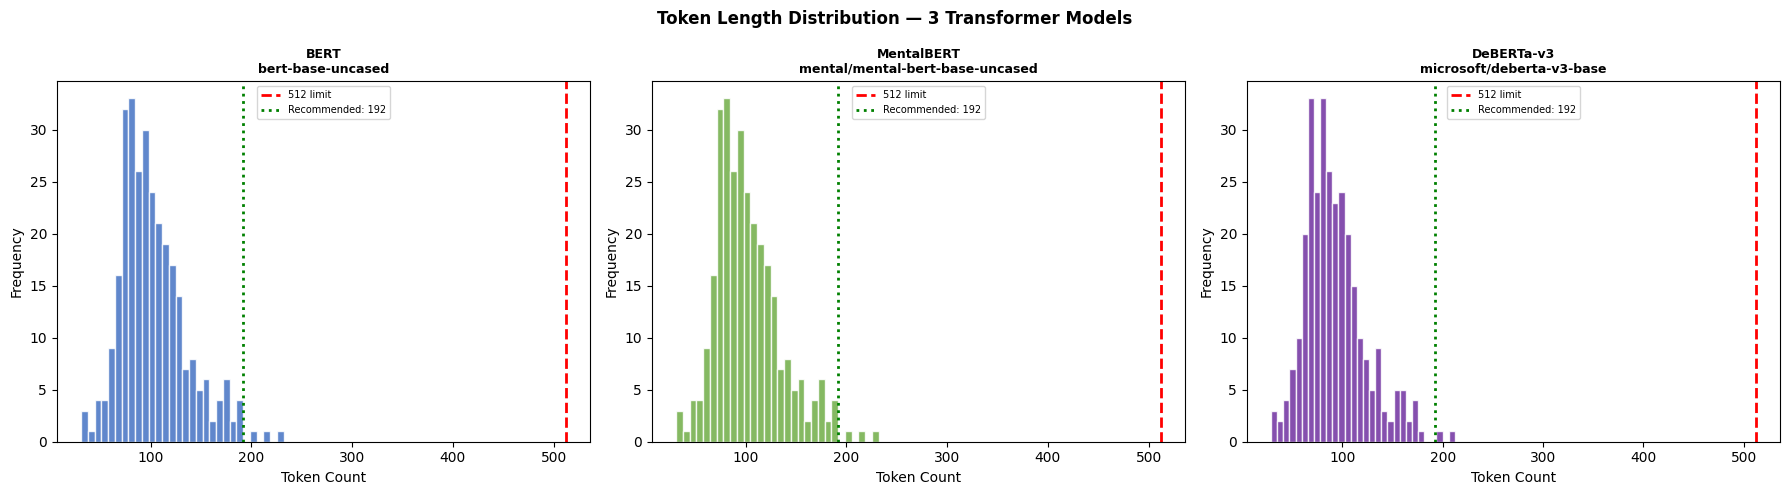

Token length visualization saved!


In [63]:
# Visualization - token length
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors    = ['#4472C4', '#70AD47', '#7030A0']

for idx, (model, color) in enumerate(zip(MODEL_REGISTRY, colors)):
    ax      = axes[idx]
    name    = model['name']
    if name not in token_stats:
        ax.text(0.5, 0.5, 'Failed to load', ha='center')
        continue
    lengths = token_stats[name]
    max_len = recommended_max_len[name]

    ax.hist(lengths, bins=30, color=color, alpha=0.85, edgecolor='white')
    ax.axvline(512,     color='red',   linewidth=2, linestyle='--', label='512 limit')
    ax.axvline(max_len, color='green', linewidth=2, linestyle=':',
               label=f'Recommended: {max_len}')
    ax.set_title(f'{name}\n{model["hf_id"]}', fontweight='bold', fontsize=9)
    ax.set_xlabel('Token Count')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=7)

plt.suptitle('Token Length Distribution — 3 Transformer Models', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}token_lengths_3models.png', dpi=150, bbox_inches='tight')
plt.show()
print('Token length visualization saved!')


In [64]:
# Save Preprocessed Data 
SAVE_COLS = [
    'text',               # original — used by ML baselines directly
    'text_for_bert',      # bert-base-uncased
    'text_for_mentalbert',# mental/mental-bert-base-uncased
    'text_for_deberta',   # microsoft/deberta-v3-base
    'label',              # 0/1 → Head 1A
    'subreddit',          # category name
    'subreddit_label',    # 0-9 → Head 1B
    'confidence',
    'sentiment',
]

train_final[SAVE_COLS].to_csv(f'{DATA_OUTPUT_DIR}dreaddit_train.csv', index=False)
val_df[SAVE_COLS].to_csv(f'{DATA_OUTPUT_DIR}dreaddit_val.csv',        index=False)
test_df[SAVE_COLS].to_csv(f'{DATA_OUTPUT_DIR}dreaddit_test.csv',      index=False)

# Metadata
metadata = {
    'dataset'  : 'Dreaddit',
    'task'     : 'Stress Detection — Head 1',
    'approach' : '3 Transformers + 2 ML Baselines',
    'splits'   : {
        'train': len(train_final),
        'val'  : len(val_df),
        'test' : len(test_df)
    },
    'models' : {
        m['name']: {
            'hf_id'    : m['hf_id'],
            'text_col' : m['text_col'],
            'max_len'  : recommended_max_len.get(m['name'], 512),
            'lowercase': m['lowercase'],
            'note'     : m['note'],
        }
        for m in MODEL_REGISTRY
    },
    'ml_baselines': {
        'LR' : {
            'name'    : 'TF-IDF + Logistic Regression',
            'text_col': 'text',    # raw text
        },
        'SVM': {
            'name'    : 'TF-IDF + SVM',
            'text_col': 'text',    # raw text
        }
    },
    'labels' : {
        'head1a': {'0': 'Not Stressed', '1': 'Stressed'},
        'head1b': {str(k): v for k, v in SUBREDDIT_ID2NAME.items()}
    },
    'class_weights': {
        'head1a': [float(x) for x in weights_binary.round(4)],
        'head1b': [float(x) for x in weights_sub.round(4)]
    },
    'num_labels': {
        'head1a': 2,
        'head1b': len(subreddit_encoder.classes_)
    },
    'random_seed'  : RANDOM_SEED,
    'preprocessing': {
        'contractions'      : f'{len(CONTRACTIONS)} patterns',
        'negation_preserved': True,
        'repeated_chars'    : True,
        'punctuation_norm'  : True,
        'stopword_removal'  : False,
        'lemmatization'     : False,
        'ml_baseline_note'  : 'Raw text used — TfidfVectorizer handles tokenization',
    }
}

with open(f'{DATA_OUTPUT_DIR}metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('All files saved!')
print(f'  dreaddit_train.csv :{len(train_final)} rows')
print(f'  dreaddit_val.csv   :{len(val_df)} rows')
print(f'  dreaddit_test.csv  :{len(test_df)} rows')



All files saved!
  dreaddit_train.csv :2258 rows
  dreaddit_val.csv   :566 rows
  dreaddit_test.csv  :715 rows


In [65]:
df = pd.read_csv(f'{DATA_OUTPUT_DIR}dreaddit_train.csv')
df.head()

,text,text_for_bert,text_for_mentalbert,text_for_deberta,label,subreddit,subreddit_label,confidence,sentiment
0,We get no child support and are doing well fin...,we get no child support and are doing well fin...,we get no child support and are doing well fin...,we get no child support and are doing well fin...,1,domesticviolence,3,0.6,0.200000
1,"&#x200B; Hey everyone, Being that Hurricane Fl...","hey everyone, being that hurricane florence ju...","hey everyone, being that hurricane florence ju...","hey everyone, being that hurricane florence ju...",1,stress,8,1.0,0.080093
2,"Woke up 4 days later, intubated and paralyzed....","woke up 4 days later, intubated and paralyzed....","woke up 4 days later, intubated and paralyzed....","woke up 4 days later, intubated and paralyzed....",0,ptsd,6,0.8,0.200000
3,"I’m also quite intellectual, I can speak 2 lan...","i m also quite intellectual, i can speak 2 lan...","i m also quite intellectual, i can speak 2 lan...","also quite intellectual, can speak 2 languages...",1,relationships,7,0.8,0.107018
4,I don't need that. This sucks but is far from ...,i do not need that. this sucks but is far from...,i do not need that. this sucks but is far from...,do not need that. this sucks but is far from h...,1,assistance,2,0.6,-0.225000


In [66]:
df.columns.tolist()

['text',
 'text_for_bert',
 'text_for_mentalbert',
 'text_for_deberta',
 'label',
 'subreddit',
 'subreddit_label',
 'confidence',
 'sentiment']